In [1]:
########################################################################
# CELL 1: INSTALL REQUIRED LIBRARIES
########################################################################

!pip install -q librosa soundfile opencv-python-headless pysptk tqdm pyworld

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.9/461.9 kB 24.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 24.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
########################################################################
# CELL 2: IMPORTS + DEVICE SETUP
########################################################################

import os
import cv2
import random
import numpy as np
import librosa
import soundfile as sf
import pyworld as pw
import pysptk
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
########################################################################
# CELL 3: GOOGLE DRIVE MOUNT + EXTRACT DATASET
########################################################################

import zipfile
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

CHECKPOINT_DIR = "/content/drive/MyDrive/vid2voc_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- Locate and extract the zipped dataset ---
ZIP_PATH = "/content/drive/MyDrive/Speech Reconstruction Dataset.zip"
EXTRACT_TO = "/content/dataset"

if os.path.exists(EXTRACT_TO) and any(os.scandir(EXTRACT_TO)):
    print(f"Dataset already extracted at {EXTRACT_TO}, skipping extraction.")
else:
    print(f"Extracting {ZIP_PATH} ...")
    os.makedirs(EXTRACT_TO, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_TO)
    print("Extraction complete.")

# --- Auto-detect the actual root (handles nested folder from zip) ---
# The zip might extract as EXTRACT_TO/Speech Reconstruction Dataset/s1/...
# or directly as EXTRACT_TO/s1/...
candidate = EXTRACT_TO
for entry in os.listdir(candidate):
    full = os.path.join(candidate, entry)
    if os.path.isdir(full) and entry.startswith("Speech"):
        candidate = full
        break

DATASET_ROOT = candidate
SPEAKERS = ["s1", "s2", "s3", "s4", "s5"]

print(f"\nDataset root: {DATASET_ROOT}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")

for sp in SPEAKERS:
    vdir = os.path.join(DATASET_ROOT, sp, "video")
    adir = os.path.join(DATASET_ROOT, sp, "audio")
    print(f"  {sp}: video={os.path.isdir(vdir)}, audio={os.path.isdir(adir)}")

Mounted at /content/drive
Extracting /content/drive/MyDrive/Speech Reconstruction Dataset.zip ...
Extraction complete.

Dataset root: /content/dataset/Speech Reconstruction Dataset
Checkpoint dir: /content/drive/MyDrive/vid2voc_checkpoints
  s1: video=True, audio=True
  s2: video=True, audio=True
  s3: video=True, audio=True
  s4: video=True, audio=True
  s5: video=True, audio=True


In [4]:
########################################################################
# CELL 4: SCAN DATASET + MATCH VIDEO-AUDIO PAIRS
########################################################################

pairs = []

for sp in SPEAKERS:
    vdir = os.path.join(DATASET_ROOT, sp, "video")
    adir = os.path.join(DATASET_ROOT, sp, "audio")

    if not os.path.isdir(vdir) or not os.path.isdir(adir):
        print(f"Skipping {sp}: missing video/ or audio/ folder")
        continue

    video_files = {os.path.splitext(f)[0]: os.path.join(vdir, f)
                   for f in os.listdir(vdir) if f.lower().endswith('.mpg')}
    audio_files = {os.path.splitext(f)[0]: os.path.join(adir, f)
                   for f in os.listdir(adir) if f.lower().endswith('.wav')}

    matched = set(video_files.keys()) & set(audio_files.keys())
    for name in sorted(matched):
        pairs.append((sp, video_files[name], audio_files[name]))

    print(f"  {sp}: {len(matched)} matched pairs")

print(f"\nTotal pairs: {len(pairs)}")

if pairs:
    sp, vp, ap = pairs[0]
    print(f"\nSample: speaker={sp}")
    print(f"  Video: {vp}")
    print(f"  Audio: {ap}")

random.seed(42)
random.shuffle(pairs)
val_size = max(1, int(len(pairs) * 0.1))
val_pairs = pairs[:val_size]
train_pairs = pairs[val_size:]
print(f"\nTrain: {len(train_pairs)}, Validation: {len(val_pairs)}")

  s1: 1000 matched pairs
  s2: 1000 matched pairs
  s3: 1000 matched pairs
  s4: 1000 matched pairs
  s5: 1000 matched pairs

Total pairs: 5000

Sample: speaker=s1
  Video: /content/dataset/Speech Reconstruction Dataset/s1/video/bbaf2n.mpg
  Audio: /content/dataset/Speech Reconstruction Dataset/s1/audio/bbaf2n.wav

Train: 4500, Validation: 500


In [5]:
########################################################################
# CELL 5: CONFIGURATION (FOLLOWING PAPER)
########################################################################

# Video
NUM_FRAMES = 75
FRAME_H = 64
FRAME_W = 96
CONTEXT_FRAMES = 7

# Audio (WORLD vocoder)
SAMPLE_RATE = 50000
HOP_SIZE = 250
SP_DIM = 60
AP_DIM = 5
AUDIO_FRAMES_PER_VIDEO = 8

# LSP (auxiliary)
LPC_ORDER = 16
LSP_DIM = LPC_ORDER + 1

# Training
BATCH_SIZE = 16
DROPOUT_P = 0.2
LEARNING_RATE = 0.0001
BETA1 = 0.5
BETA2 = 0.9

# Loss weights (paper Eq. 3)
LAMBDA_SP = 600
LAMBDA_AP = 50
LAMBDA_F0 = 10
LAMBDA_VUV = 10
LAMBDA_LSP = 1
LAMBDA_SUM = LAMBDA_SP + LAMBDA_AP + LAMBDA_F0 + LAMBDA_VUV + LAMBDA_LSP

print("Configuration loaded (vid2voc paper)")
print(f"  Video: {NUM_FRAMES} frames, {FRAME_H}x{FRAME_W}")
print(f"  Audio: SR={SAMPLE_RATE}, hop={HOP_SIZE}")
print(f"  SP={SP_DIM}d, AP={AP_DIM}d, LSP={LSP_DIM}d")

Configuration loaded (vid2voc paper)
  Video: 75 frames, 64x96
  Audio: SR=50000, hop=250
  SP=60d, AP=5d, LSP=17d


In [6]:
########################################################################
# CELL 6: AUDIO PREPROCESSING - WORLD VOCODER FEATURES
# Paper Section 2.2
########################################################################

def extract_world_features(audio_path, sr=SAMPLE_RATE, hop=HOP_SIZE):
    y, orig_sr = librosa.load(audio_path, sr=sr, mono=True)
    y = y.astype(np.float64)

    _f0, t = pw.dio(y, sr, frame_period=hop / sr * 1000)
    f0 = pw.stonemask(y, _f0, t, sr)
    sp = pw.cheaptrick(y, f0, t, sr)
    ap = pw.d4c(y, f0, t, sr)

    # SP to 60 log MFSCs
    n_fft = sp.shape[1]
    mel_basis = librosa.filters.mel(sr=sr, n_fft=(n_fft - 1) * 2, n_mels=SP_DIM)
    if mel_basis.shape[1] > sp.shape[1]:
        mel_basis = mel_basis[:, :sp.shape[1]]
    elif mel_basis.shape[1] < sp.shape[1]:
        pad = np.zeros((mel_basis.shape[0], sp.shape[1] - mel_basis.shape[1]))
        mel_basis = np.concatenate([mel_basis, pad], axis=1)

    log_sp = np.log(np.maximum(sp, 1e-10))
    mfsc = np.dot(log_sp, mel_basis.T).astype(np.float32)

    # AP to 5 band coefficients
    ap_log = np.log(np.maximum(ap, 1e-10))
    n_freq = ap_log.shape[1]
    band_edges = np.linspace(0, n_freq, AP_DIM + 1, dtype=int)
    ap_reduced = np.zeros((ap_log.shape[0], AP_DIM), dtype=np.float32)
    for i in range(AP_DIM):
        s, e = band_edges[i], band_edges[i + 1]
        if e > s:
            ap_reduced[:, i] = np.mean(ap_log[:, s:e], axis=1)

    vuv = (f0 > 0).astype(np.float32)

    return {
        'mfsc': mfsc, 'f0': f0.astype(np.float32),
        'ap': ap_reduced, 'vuv': vuv,
        'sp_full': sp, 'ap_full': ap,
    }


def extract_lsp_auxiliary(audio_path, sr=8000, lpc_order=LPC_ORDER):
    y, _ = librosa.load(audio_path, sr=sr, mono=True)
    frame_len = int(sr * 0.04)
    hop_len = int(sr * 0.02)

    lsp_vectors = []
    for start in range(0, len(y) - frame_len + 1, hop_len):
        frame = y[start:start + frame_len]
        windowed = frame * np.hamming(frame_len)
        try:
            lpc_coeffs = pysptk.lpc(windowed.astype(np.float64), order=lpc_order)
            lsp = pysptk.lpc2lsp(lpc_coeffs)
            if len(lsp) == lpc_order + 1:
                lsp_vectors.append(lsp.astype(np.float32))
            else:
                lsp_vectors.append(np.zeros(lpc_order + 1, dtype=np.float32))
        except Exception:
            lsp_vectors.append(np.zeros(lpc_order + 1, dtype=np.float32))

    if lsp_vectors:
        return np.array(lsp_vectors)
    return np.zeros((1, lpc_order + 1), dtype=np.float32)


# Test
if pairs:
    sp_id, vp, ap = pairs[0]
    print(f"Testing on: {os.path.basename(ap)}")
    feats = extract_world_features(ap)
    print(f"  MFSC: {feats['mfsc'].shape}, F0: {feats['f0'].shape}")
    print(f"  AP: {feats['ap'].shape}, VUV: {feats['vuv'].shape}")
    print(f"  Voiced: {feats['vuv'].mean()*100:.1f}%")
    lsp = extract_lsp_auxiliary(ap)
    print(f"  LSP: {lsp.shape}")

Testing on: lrbk9s.wav
  MFSC: (601, 60), F0: (601,)
  AP: (601, 5), VUV: (601,)
  Voiced: 61.4%
  LSP: (149, 17)


Video frames: (75, 64, 96), range: [-0.86, 0.83]


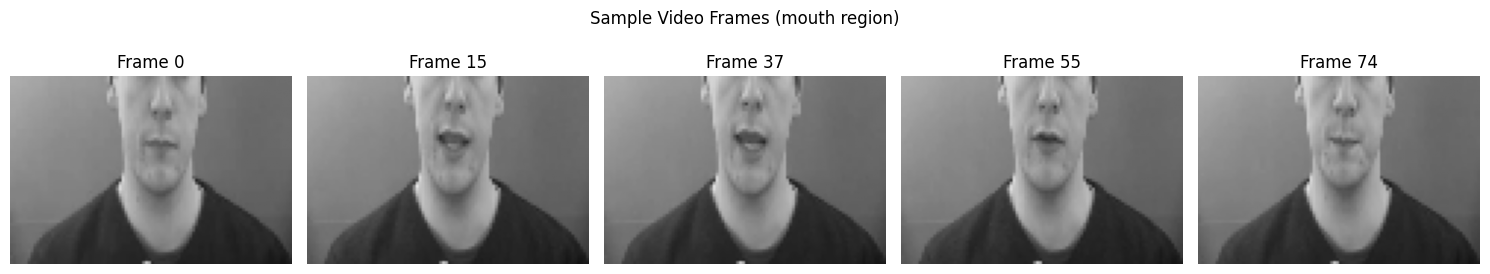

In [7]:
########################################################################
# CELL 7: VIDEO PREPROCESSING (PAPER SECTION 2.2)
########################################################################

def extract_video_frames(video_path, num_frames=NUM_FRAMES,
                         frame_h=FRAME_H, frame_w=FRAME_W):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    all_frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        h = gray.shape[0]
        mouth = gray[h // 2:, :]
        resized = cv2.resize(mouth, (frame_w, frame_h))
        all_frames.append(resized)
    cap.release()

    if len(all_frames) == 0:
        raise ValueError(f"No frames from: {video_path}")

    all_frames = np.array(all_frames, dtype=np.float32)
    all_frames = (all_frames / 127.5) - 1.0

    if len(all_frames) >= num_frames:
        indices = np.linspace(0, len(all_frames) - 1, num_frames, dtype=int)
        frames = all_frames[indices]
    else:
        pad_count = num_frames - len(all_frames)
        padding = np.repeat(all_frames[-1:], pad_count, axis=0)
        frames = np.concatenate([all_frames, padding], axis=0)

    return frames

if pairs:
    sp_id, vp, ap = pairs[0]
    frames = extract_video_frames(vp)
    print(f"Video frames: {frames.shape}, range: [{frames.min():.2f}, {frames.max():.2f}]")

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i, idx in enumerate([0, 15, 37, 55, 74]):
        axes[i].imshow(frames[idx], cmap='gray', vmin=-1, vmax=1)
        axes[i].set_title(f"Frame {idx}")
        axes[i].axis('off')
    plt.suptitle("Sample Video Frames (mouth region)")
    plt.tight_layout()
    plt.show()

In [8]:
########################################################################
# CELL 8: COMPUTE NORMALIZATION STATISTICS
# Paper: min-max normalization using training set statistics
########################################################################

print("Computing normalization statistics...")

stat_pairs = train_pairs[:min(500, len(train_pairs))]

all_mfsc, all_f0, all_ap, all_lsp = [], [], [], []

for i, (sp, vp, ap) in enumerate(tqdm(stat_pairs, desc="Stats")):
    try:
        feats = extract_world_features(ap)
        all_mfsc.append(feats['mfsc'])
        voiced_f0 = feats['f0'][feats['f0'] > 0]
        if len(voiced_f0) > 0:
            all_f0.append(voiced_f0)
        all_ap.append(feats['ap'])
        lsp = extract_lsp_auxiliary(ap)
        all_lsp.append(lsp)
    except Exception as e:
        print(f"  Skip: {e}")

all_mfsc = np.concatenate(all_mfsc, axis=0)
all_f0_cat = np.concatenate(all_f0) if all_f0 else np.array([100.0, 300.0])
all_ap = np.concatenate(all_ap, axis=0)
all_lsp = np.concatenate(all_lsp, axis=0)

MFSC_MIN = all_mfsc.min(axis=0)
MFSC_MAX = all_mfsc.max(axis=0)
F0_MIN = float(all_f0_cat.min())
F0_MAX = float(all_f0_cat.max())
AP_MIN = all_ap.min(axis=0)
AP_MAX = all_ap.max(axis=0)
LSP_MEAN = all_lsp.mean(axis=0)
LSP_STD = all_lsp.std(axis=0) + 1e-8

MFSC_RANGE = np.maximum(MFSC_MAX - MFSC_MIN, 1e-8)
F0_RANGE = max(F0_MAX - F0_MIN, 1e-8)
AP_RANGE = np.maximum(AP_MAX - AP_MIN, 1e-8)

print(f"MFSC: [{MFSC_MIN.mean():.2f}, {MFSC_MAX.mean():.2f}]")
print(f"F0: [{F0_MIN:.1f}, {F0_MAX:.1f}] Hz")
print(f"AP: [{AP_MIN.mean():.4f}, {AP_MAX.mean():.4f}]")
print(f"Computed from {len(stat_pairs)} samples")

Computing normalization statistics...


Stats: 100%|██████████| 500/500 [08:44<00:00,  1.05s/it]

MFSC: [-1.71, 0.07]
F0: [58.4, 555.4] Hz
AP: [-2.2605, -0.0000]
Computed from 500 samples


In [9]:
########################################################################
# CELL 9: PYTORCH DATASET
########################################################################

class Vid2VocDataset(Dataset):
    def __init__(self, pairs, augment=False):
        self.pairs = pairs
        self.augment = augment
        self.total_audio_frames = NUM_FRAMES * AUDIO_FRAMES_PER_VIDEO

    def __len__(self):
        return len(self.pairs)

    def _resample(self, feat, target_len):
        if len(feat.shape) == 1:
            feat = feat[:, None]
            squeeze = True
        else:
            squeeze = False
        curr = feat.shape[0]
        if curr == target_len:
            result = feat
        elif curr > target_len:
            idx = np.linspace(0, curr - 1, target_len, dtype=int)
            result = feat[idx]
        else:
            pad = np.repeat(feat[-1:], target_len - curr, axis=0)
            result = np.concatenate([feat, pad], axis=0)
        return result.squeeze(-1) if squeeze else result

    def __getitem__(self, idx):
        sp_id, video_path, audio_path = self.pairs[idx]
        try:
            frames = extract_video_frames(video_path)
            if self.augment and random.random() > 0.5:
                frames = frames[:, :, ::-1].copy()

            feats = extract_world_features(audio_path)
            T = self.total_audio_frames

            mfsc = self._resample(feats['mfsc'], T)
            f0 = self._resample(feats['f0'], T)
            ap = self._resample(feats['ap'], T)
            vuv = self._resample(feats['vuv'], T)

            mfsc = (mfsc - MFSC_MIN) / MFSC_RANGE
            f0_norm = np.zeros_like(f0)
            voiced = f0 > 0
            if voiced.any():
                f0_norm[voiced] = (f0[voiced] - F0_MIN) / F0_RANGE
            f0 = f0_norm
            ap = (ap - AP_MIN) / AP_RANGE

            mfsc = mfsc.reshape(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO, SP_DIM)
            f0 = f0.reshape(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO)
            ap = ap.reshape(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO, AP_DIM)
            vuv = vuv.reshape(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO)

            lsp_raw = extract_lsp_auxiliary(audio_path)
            lsp_rs = self._resample(lsp_raw, NUM_FRAMES)
            lsp_norm = (lsp_rs - LSP_MEAN) / LSP_STD

            frames_t = torch.FloatTensor(frames).unsqueeze(0)
            return (frames_t,
                    torch.FloatTensor(mfsc),
                    torch.FloatTensor(f0),
                    torch.FloatTensor(ap),
                    torch.FloatTensor(vuv),
                    torch.FloatTensor(lsp_norm))

        except Exception as e:
            print(f"Error idx {idx}: {e}")
            return (torch.zeros(1, NUM_FRAMES, FRAME_H, FRAME_W),
                    torch.zeros(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO, SP_DIM),
                    torch.zeros(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO),
                    torch.zeros(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO, AP_DIM),
                    torch.zeros(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO),
                    torch.zeros(NUM_FRAMES, LSP_DIM))


train_dataset = Vid2VocDataset(train_pairs, augment=True)
val_dataset = Vid2VocDataset(val_pairs, augment=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples, {len(val_loader)} batches")

batch = next(iter(train_loader))
names = ['frames', 'mfsc', 'f0', 'ap', 'vuv', 'lsp']
for name, t in zip(names, batch):
    print(f"  {name:8s}: {t.shape}")

Train: 4500 samples, 281 batches
Val:   500 samples, 32 batches
  frames  : torch.Size([16, 1, 75, 64, 96])
  mfsc    : torch.Size([16, 75, 8, 60])
  f0      : torch.Size([16, 75, 8])
  ap      : torch.Size([16, 75, 8, 5])
  vuv     : torch.Size([16, 75, 8])
  lsp     : torch.Size([16, 75, 17])


In [10]:
########################################################################
# CELL 9B: PRECOMPUTE AND CACHE ALL FEATURES
# Run once — saves WORLD + LSP features to disk for fast training
########################################################################

import pickle

CACHE_DIR = "/content/drive/MyDrive/vid2voc_feature_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def get_cache_key(audio_path, speaker):
    name = os.path.splitext(os.path.basename(audio_path))[0]
    return f"{speaker}_{name}"

def precompute_all(pairs, cache_dir=CACHE_DIR):
    skipped = 0
    computed = 0
    total = len(pairs)

    for i, (sp_id, vp, ap) in enumerate(tqdm(pairs, desc="Precomputing features")):
        key = get_cache_key(ap, sp_id)
        cache_file = os.path.join(cache_dir, f"{key}.pkl")

        if os.path.exists(cache_file):
            skipped += 1
            continue

        try:
            feats = extract_world_features(ap)
            lsp = extract_lsp_auxiliary(ap)
            video_frames = extract_video_frames(vp)

            data = {
                'mfsc': feats['mfsc'],
                'f0': feats['f0'],
                'ap': feats['ap'],
                'vuv': feats['vuv'],
                'lsp': lsp,
                'video': video_frames,
            }

            with open(cache_file, 'wb') as f:
                pickle.dump(data, f, protocol=4)

            computed += 1
        except Exception as e:
            print(f"  Failed {os.path.basename(ap)}: {e}")
            skipped += 1

        if (i + 1) % 200 == 0:
            print(f"  Progress: {i+1}/{total} (computed={computed}, cached={skipped})")

    print(f"\nDone! Computed: {computed}, Already cached: {skipped}")
    print(f"Cache dir: {cache_dir}")

# Run it
precompute_all(train_pairs + val_pairs)

Precomputing features: 100%|██████████| 5000/5000 [00:22<00:00, 219.82it/s] 


Done! Computed: 0, Already cached: 5000
Cache dir: /content/drive/MyDrive/vid2voc_feature_cache


In [11]:
import shutil
LOCAL_CACHE = "/content/feature_cache_local"
if not os.path.exists(LOCAL_CACHE):
    print("Copying cache to local disk...")
    shutil.copytree(CACHE_DIR, LOCAL_CACHE)
    print("Done!")
CACHE_DIR = LOCAL_CACHE

Copying cache to local disk...
Done!


In [12]:
########################################################################
# CELL 10: FAST CACHED DATASET
########################################################################

class Vid2VocCachedDataset(Dataset):
    def __init__(self, pairs, augment=False, cache_dir=CACHE_DIR):
        self.pairs = pairs
        self.augment = augment
        self.cache_dir = cache_dir
        self.total_audio_frames = NUM_FRAMES * AUDIO_FRAMES_PER_VIDEO

    def __len__(self):
        return len(self.pairs)

    def _resample(self, feat, target_len):
        if len(feat.shape) == 1:
            feat = feat[:, None]
            squeeze = True
        else:
            squeeze = False
        curr = feat.shape[0]
        if curr == target_len:
            result = feat
        elif curr > target_len:
            idx = np.linspace(0, curr - 1, target_len, dtype=int)
            result = feat[idx]
        else:
            pad = np.repeat(feat[-1:], target_len - curr, axis=0)
            result = np.concatenate([feat, pad], axis=0)
        return result.squeeze(-1) if squeeze else result

    def __getitem__(self, idx):
        sp_id, vp, ap = self.pairs[idx]
        key = get_cache_key(ap, sp_id)
        cache_file = os.path.join(self.cache_dir, f"{key}.pkl")

        try:
            with open(cache_file, 'rb') as f:
                data = pickle.load(f)

            frames = data['video']
            if self.augment and random.random() > 0.5:
                frames = frames[:, :, ::-1].copy()

            T = self.total_audio_frames
            mfsc = self._resample(data['mfsc'], T)
            f0 = self._resample(data['f0'], T)
            ap = self._resample(data['ap'], T)
            vuv = self._resample(data['vuv'], T)

            mfsc = (mfsc - MFSC_MIN) / MFSC_RANGE
            f0_norm = np.zeros_like(f0)
            voiced = f0 > 0
            if voiced.any():
                f0_norm[voiced] = (f0[voiced] - F0_MIN) / F0_RANGE
            f0 = f0_norm
            ap = (ap - AP_MIN) / AP_RANGE

            mfsc = mfsc.reshape(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO, SP_DIM)
            f0 = f0.reshape(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO)
            ap = ap.reshape(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO, AP_DIM)
            vuv = vuv.reshape(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO)

            lsp_rs = self._resample(data['lsp'], NUM_FRAMES)
            lsp_norm = (lsp_rs - LSP_MEAN) / LSP_STD

            frames_t = torch.FloatTensor(frames).unsqueeze(0)
            return (frames_t,
                    torch.FloatTensor(mfsc),
                    torch.FloatTensor(f0),
                    torch.FloatTensor(ap),
                    torch.FloatTensor(vuv),
                    torch.FloatTensor(lsp_norm))

        except Exception as e:
            print(f"Cache miss idx {idx}: {e}")
            return (torch.zeros(1, NUM_FRAMES, FRAME_H, FRAME_W),
                    torch.zeros(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO, SP_DIM),
                    torch.zeros(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO),
                    torch.zeros(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO, AP_DIM),
                    torch.zeros(NUM_FRAMES, AUDIO_FRAMES_PER_VIDEO),
                    torch.zeros(NUM_FRAMES, LSP_DIM))


train_dataset = Vid2VocCachedDataset(train_pairs, augment=True)
val_dataset = Vid2VocCachedDataset(val_pairs, augment=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples, {len(val_loader)} batches")

# Test speed
import time
t0 = time.time()
batch = next(iter(train_loader))
t1 = time.time()
print(f"First batch loaded in {t1-t0:.2f}s (was ~13s before)")
for name, t in zip(['frames','mfsc','f0','ap','vuv','lsp'], batch):
    print(f"  {name:8s}: {t.shape}")

Train: 4500 samples, 281 batches
Val:   500 samples, 32 batches
First batch loaded in 0.85s (was ~13s before)
  frames  : torch.Size([16, 1, 75, 64, 96])
  mfsc    : torch.Size([16, 75, 8, 60])
  f0      : torch.Size([16, 75, 8])
  ap      : torch.Size([16, 75, 8, 5])
  vuv     : torch.Size([16, 75, 8])
  lsp     : torch.Size([16, 75, 17])


In [13]:
########################################################################
# CELL 10B: MODEL (PAPER FIGURE 1 + TABLE 1)
# Video Encoder (5x Conv3D) -> GRU -> Decoders (SP, AP, VUV, F0, LSP)
########################################################################

class VideoEncoder(nn.Module):
    def __init__(self, dp=DROPOUT_P):
        super().__init__()
        self.conv1 = nn.Conv3d(1, 64, (7,4,4), (1,2,2), (0,1,1))
        self.bn1 = nn.BatchNorm3d(64)
        self.drop1 = nn.Dropout3d(dp)
        self.conv2 = nn.Conv3d(64, 128, (1,4,4), (1,2,2), (0,1,1))
        self.bn2 = nn.BatchNorm3d(128)
        self.drop2 = nn.Dropout3d(dp)
        self.conv3 = nn.Conv3d(128, 256, (1,4,4), (1,2,2), (0,1,1))
        self.bn3 = nn.BatchNorm3d(256)
        self.drop3 = nn.Dropout3d(dp)
        self.conv4 = nn.Conv3d(256, 512, (1,4,4), (1,2,2), (0,1,1))
        self.bn4 = nn.BatchNorm3d(512)
        self.drop4 = nn.Dropout3d(dp)
        self.conv5 = nn.Conv3d(512, 128, (1,4,6), (1,1,1), (0,0,0))
        self.pool = nn.AdaptiveAvgPool3d((1, 1, 1))

    def forward(self, x):
        x = self.drop1(F.relu(self.bn1(self.conv1(x))))
        x = self.drop2(F.relu(self.bn2(self.conv2(x))))
        x = self.drop3(F.relu(self.bn3(self.conv3(x))))
        x = self.drop4(F.relu(self.bn4(self.conv4(x))))
        x = torch.tanh(self.conv5(x))
        x = self.pool(x)
        return x.view(x.size(0), 128)


class SPDecoder(nn.Module):
    def __init__(self, dp=DROPOUT_P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dp),
            nn.Linear(256, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dp),
            nn.Linear(512, SP_DIM * AUDIO_FRAMES_PER_VIDEO), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x).view(x.size(0), SP_DIM, AUDIO_FRAMES_PER_VIDEO)


class APDecoder(nn.Module):
    def __init__(self, dp=DROPOUT_P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dp),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dp),
            nn.Linear(64, AP_DIM * AUDIO_FRAMES_PER_VIDEO), nn.ReLU(),
        )
    def forward(self, x, vuv):
        out = self.net(x).view(x.size(0), AP_DIM, AUDIO_FRAMES_PER_VIDEO)
        return out * vuv.unsqueeze(1)


class VUVDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(128, AUDIO_FRAMES_PER_VIDEO)
    def forward(self, x):
        return torch.sigmoid(self.fc(x))


class F0Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(128, AUDIO_FRAMES_PER_VIDEO)
    def forward(self, x, vuv):
        return torch.sigmoid(self.fc(x)) * vuv


class LSPDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, LSP_DIM))
    def forward(self, x):
        return self.fc(x)


class Vid2Voc(nn.Module):
    def __init__(self, dp=DROPOUT_P):
        super().__init__()
        self.encoder = VideoEncoder(dp)
        self.gru = nn.GRU(128, 128, 1, batch_first=True)
        self.gru_bn = nn.BatchNorm1d(128)
        self.gru_drop = nn.Dropout(dp)
        self.sp_dec = SPDecoder(dp)
        self.ap_dec = APDecoder(dp)
        self.vuv_dec = VUVDecoder()
        self.f0_dec = F0Decoder()
        self.lsp_dec = LSPDecoder()
        self.ctx = CONTEXT_FRAMES

    def forward(self, video):
        B, C, T, H, W = video.shape
        pad = self.ctx // 2
        padded = F.pad(video, (0,0,0,0,pad,pad), mode='replicate')

        chunks = []
        for t in range(T):
            chunks.append(padded[:, :, t:t+self.ctx, :, :])
        all_chunks = torch.stack(chunks, dim=1).view(B*T, C, self.ctx, H, W)

        enc = self.encoder(all_chunks).view(B, T, 128)
        gru_out, _ = self.gru(enc)
        gru_out = gru_out.permute(0,2,1)
        gru_out = self.gru_drop(F.relu(self.gru_bn(gru_out)))
        gru_out = gru_out.permute(0,2,1)

        flat = gru_out.reshape(B*T, 128)
        vuv = self.vuv_dec(flat)
        sp = self.sp_dec(flat)
        ap = self.ap_dec(flat, vuv)
        f0 = self.f0_dec(flat, vuv)
        lsp = self.lsp_dec(flat)

        return {
            'sp': sp.view(B,T,SP_DIM,AUDIO_FRAMES_PER_VIDEO),
            'ap': ap.view(B,T,AP_DIM,AUDIO_FRAMES_PER_VIDEO),
            'vuv': vuv.view(B,T,AUDIO_FRAMES_PER_VIDEO),
            'f0': f0.view(B,T,AUDIO_FRAMES_PER_VIDEO),
            'lsp': lsp.view(B,T,LSP_DIM),
        }

model = Vid2Voc().to(device)
nparams = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Vid2Voc parameters: {nparams:,}")

dummy = torch.randn(2, 1, NUM_FRAMES, FRAME_H, FRAME_W).to(device)
with torch.no_grad():
    out = model(dummy)
for k, v in out.items():
    print(f"  {k:4s}: {v.shape}")

Vid2Voc parameters: 4,886,441
  sp  : torch.Size([2, 75, 60, 8])
  ap  : torch.Size([2, 75, 5, 8])
  vuv : torch.Size([2, 75, 8])
  f0  : torch.Size([2, 75, 8])
  lsp : torch.Size([2, 75, 17])


In [14]:
########################################################################
# CELL 11: MULTI-TASK LOSS (PAPER EQ. 3)
########################################################################

class Vid2VocLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.w_sp = LAMBDA_SP / LAMBDA_SUM
        self.w_ap = LAMBDA_AP / LAMBDA_SUM
        self.w_f0 = LAMBDA_F0 / LAMBDA_SUM
        self.w_vuv = LAMBDA_VUV / LAMBDA_SUM
        self.w_lsp = LAMBDA_LSP / LAMBDA_SUM

    def forward(self, pred, targets):
        mfsc_t, f0_t, ap_t, vuv_t, lsp_t = targets
        sp_p = pred['sp'].permute(0,1,3,2)
        ap_p = pred['ap'].permute(0,1,3,2)

        l_sp = F.mse_loss(sp_p, mfsc_t)
        l_ap = F.mse_loss(ap_p, ap_t)
        l_f0 = F.mse_loss(pred['f0'], f0_t)
        l_vuv = F.mse_loss(pred['vuv'], vuv_t)
        l_lsp = F.mse_loss(pred['lsp'], lsp_t)

        total = (self.w_sp*l_sp + self.w_ap*l_ap + self.w_f0*l_f0 +
                 self.w_vuv*l_vuv + self.w_lsp*l_lsp)

        return total, {
            'total': total.item(), 'sp': l_sp.item(), 'ap': l_ap.item(),
            'f0': l_f0.item(), 'vuv': l_vuv.item(), 'lsp': l_lsp.item(),
        }

print("Loss ready (weighted multi-task MSE)")

Loss ready (weighted multi-task MSE)


In [15]:
########################################################################
# CELL 12: TRAINING LOOP WITH CHECKPOINTING
########################################################################

def train_epoch(model, loader, optimizer, criterion, device, epoch):
    model.train()
    losses = defaultdict(float)
    n = 0
    pbar = tqdm(loader, desc=f"Epoch {epoch}")
    for batch in pbar:
        data = [b.to(device) for b in batch]
        frames, mfsc, f0, ap, vuv, lsp = data
        optimizer.zero_grad()
        pred = model(frames)
        loss, det = criterion(pred, (mfsc, f0, ap, vuv, lsp))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        for k, v in det.items():
            losses[k] += v
        n += 1
        pbar.set_postfix(loss=f"{det['total']:.4f}", sp=f"{det['sp']:.4f}")
    return {k: v/max(n,1) for k,v in losses.items()}


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    losses = defaultdict(float)
    n = 0
    for batch in loader:
        data = [b.to(device) for b in batch]
        frames, mfsc, f0, ap, vuv, lsp = data
        pred = model(frames)
        loss, det = criterion(pred, (mfsc, f0, ap, vuv, lsp))
        for k, v in det.items():
            losses[k] += v
        n += 1
    return {k: v/max(n,1) for k,v in losses.items()}


def train_model(model, train_loader, val_loader, num_epochs=100,
                save_dir=CHECKPOINT_DIR, resume_path=None):
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', 0.5, patience=10)
    criterion = Vid2VocLoss()
    best = float('inf')
    start = 1
    patience_cnt = 0
    history = defaultdict(list)
    ckpt = os.path.join(save_dir, 'vid2voc_best.pth')

    if resume_path and os.path.exists(resume_path):
        print(f"Resuming from {resume_path}")
        c = torch.load(resume_path, map_location=device, weights_only=False)
        model.load_state_dict(c['model_state_dict'])
        optimizer.load_state_dict(c['optimizer_state_dict'])
        start = c['epoch'] + 1
        best = c.get('val_loss', float('inf'))
        print(f"  Epoch {start}, best={best:.6f}")

    print(f"\nTraining vid2voc for {num_epochs} epochs, LR={LEARNING_RATE}")

    for epoch in range(start, num_epochs + 1):
        tl = train_epoch(model, train_loader, optimizer, criterion, device, epoch)
        vl = validate(model, val_loader, criterion, device)
        scheduler.step(vl['total'])

        lr = optimizer.param_groups[0]['lr']
        print(f"Ep {epoch:3d} | Train:{tl['total']:.6f} (SP:{tl['sp']:.4f}) | "
              f"Val:{vl['total']:.6f} | LR:{lr:.6f}")

        for k in tl:
            history[f'train_{k}'].append(tl[k])
        for k in vl:
            history[f'val_{k}'].append(vl[k])

        if vl['total'] < best:
            best = vl['total']
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': best,
                'norm_stats': {
                    'MFSC_MIN': MFSC_MIN, 'MFSC_MAX': MFSC_MAX,
                    'F0_MIN': F0_MIN, 'F0_MAX': F0_MAX,
                    'AP_MIN': AP_MIN, 'AP_MAX': AP_MAX,
                    'LSP_MEAN': LSP_MEAN, 'LSP_STD': LSP_STD,
                },
            }, ckpt)
            print(f"  -> Best saved (val={best:.6f})")
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 25:
                print(f"Early stopping at epoch {epoch}")
                break

    return dict(history)

print("Training functions ready")

Training functions ready


In [17]:
########################################################################
# CELL 13: RUN TRAINING
########################################################################

NUM_EPOCHS = 100

resume_from = os.path.join(CHECKPOINT_DIR, 'vid2voc_best.pth')
if not os.path.exists(resume_from):
    resume_from = None

model = Vid2Voc().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

history = train_model(model, train_loader, val_loader,
                      num_epochs=NUM_EPOCHS, resume_path=resume_from)

# Save final state regardless of best or not
final_ckpt = os.path.join(CHECKPOINT_DIR, 'vid2voc_final.pth')
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'norm_stats': {
        'MFSC_MIN': MFSC_MIN, 'MFSC_MAX': MFSC_MAX,
        'F0_MIN': F0_MIN, 'F0_MAX': F0_MAX,
        'AP_MIN': AP_MIN, 'AP_MAX': AP_MAX,
        'LSP_MEAN': LSP_MEAN, 'LSP_STD': LSP_STD,
    },
}, final_ckpt)
print(f"Final model saved to {final_ckpt}")

Parameters: 4,886,441
Resuming from /content/drive/MyDrive/vid2voc_checkpoints/vid2voc_best.pth
  Epoch 101, best=0.010103

Training vid2voc for 100 epochs, LR=0.0001
Final model saved to /content/drive/MyDrive/vid2voc_checkpoints/vid2voc_final.pth


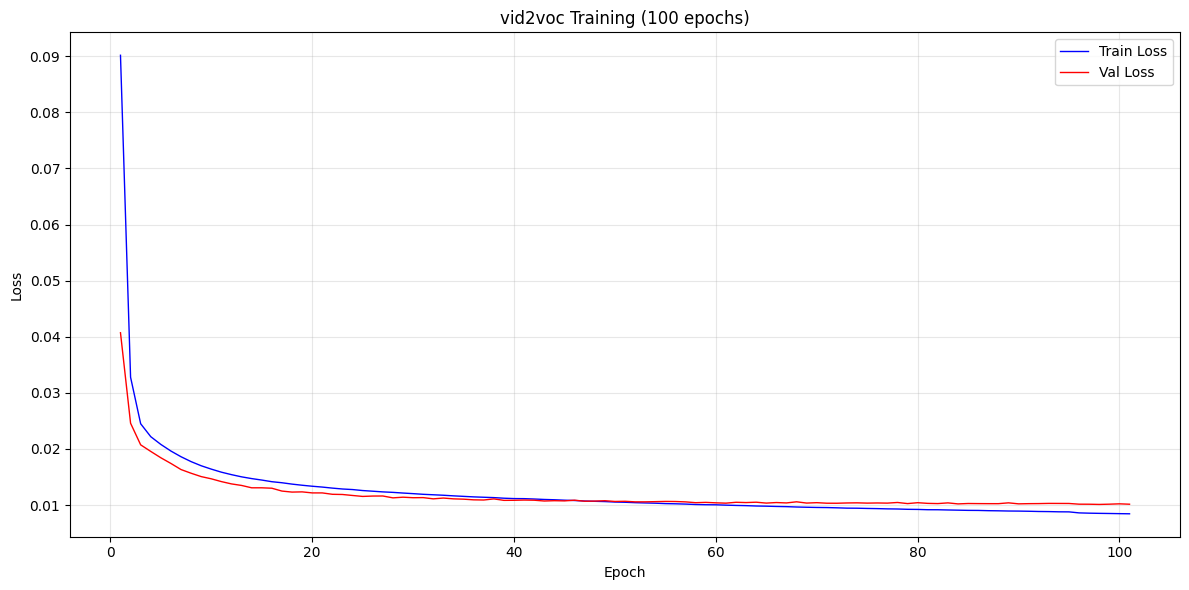

In [19]:
########################################################################
# CELL 14: PLOT TRAINING HISTORY
########################################################################

# Full training log from all sessions
all_train = [
    0.090162, 0.032781, 0.024491, 0.022187, 0.020805, 0.019624, 0.018610,
    0.017739, 0.017003, 0.016403, 0.015860, 0.015419, 0.015028, 0.014717,
    0.014455, 0.014162, 0.013975, 0.013732, 0.013531, 0.013354, 0.013204,
    0.013019, 0.012861, 0.012762, 0.012585, 0.012467, 0.012346, 0.012260,
    0.012140, 0.012033, 0.011916, 0.011831, 0.011748, 0.011640, 0.011549,
    0.011456, 0.011391, 0.011326, 0.011220, 0.011154, 0.011141, 0.011076,
    0.010997, 0.010943, 0.010867, 0.010810, 0.010716, 0.010668, 0.010622,
    0.010537, 0.010498, 0.010424, 0.010375, 0.010331, 0.010260, 0.010225,
    0.010172, 0.010096, 0.010058, 0.010046, 0.009982, 0.009933, 0.009895,
    0.009831, 0.009800, 0.009751, 0.009717, 0.009652, 0.009609, 0.009572,
    0.009553, 0.009507, 0.009449, 0.009437, 0.009396, 0.009366, 0.009320,
    0.009297, 0.009241, 0.009221, 0.009169, 0.009163, 0.009122, 0.009088,
    0.009053, 0.009042, 0.008997, 0.008973, 0.008937, 0.008924, 0.008895,
    0.008853, 0.008834, 0.008795, 0.008784, 0.008603, 0.008553, 0.008521,
    0.008497, 0.008468, 0.008442,
]

all_val = [
    0.040712, 0.024585, 0.020731, 0.019558, 0.018426, 0.017411, 0.016327,
    0.015669, 0.015071, 0.014676, 0.014180, 0.013769, 0.013495, 0.013074,
    0.013075, 0.013000, 0.012492, 0.012310, 0.012349, 0.012165, 0.012163,
    0.011917, 0.011883, 0.011707, 0.011538, 0.011604, 0.011614, 0.011282,
    0.011401, 0.011307, 0.011326, 0.011106, 0.011247, 0.011104, 0.011049,
    0.010929, 0.010899, 0.011097, 0.010835, 0.010849, 0.010891, 0.010862,
    0.010720, 0.010776, 0.010741, 0.010866, 0.010682, 0.010706, 0.010775,
    0.010642, 0.010671, 0.010572, 0.010573, 0.010608, 0.010647, 0.010631,
    0.010565, 0.010422, 0.010475, 0.010397, 0.010339, 0.010493, 0.010444,
    0.010507, 0.010349, 0.010447, 0.010378, 0.010579, 0.010353, 0.010424,
    0.010328, 0.010323, 0.010372, 0.010394, 0.010345, 0.010372, 0.010344,
    0.010459, 0.010261, 0.010419, 0.010301, 0.010263, 0.010387, 0.010205,
    0.010276, 0.010259, 0.010249, 0.010247, 0.010394, 0.010215, 0.010249,
    0.010262, 0.010295, 0.010289, 0.010282, 0.010155, 0.010148, 0.010112,
    0.010156, 0.010218, 0.010149,
]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(1, 102), all_train, 'b-', label='Train Loss', linewidth=1)
ax.plot(range(1, 102), all_val, 'r-', label='Val Loss', linewidth=1)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('vid2voc Training (100 epochs)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
########################################################################
# CELL 15: RECONSTRUCTION - PER-SAMPLE SPEECH (FINAL WORKING VERSION)
########################################################################
from scipy.ndimage import median_filter

def reconstruct_world_audio(mfsc_pred, f0_pred, ap_pred, vuv_pred,
                            audio_path,
                            sr=SAMPLE_RATE, hop=HOP_SIZE):

    T = mfsc_pred.shape[0]
    frame_period = hop / sr * 1000

    # ============================================================
    # STEP 1: Build F0 (from model)
    # ============================================================
    f0 = f0_pred * F0_RANGE + F0_MIN
    vuv_bin = (vuv_pred > 0.5)
    f0 = f0 * vuv_bin.astype(np.float64)

    # Smooth F0
    voiced = f0 > 0
    if voiced.any():
        f0_smooth = median_filter(f0, size=5)
        f0[voiced] = f0_smooth[voiced]

    f0 = f0.astype(np.float64)

    # ============================================================
    # STEP 2: Extract WORLD features from THIS sample
    # ============================================================
    y_ref, _ = librosa.load(audio_path, sr=sr, mono=True)
    y_ref = y_ref.astype(np.float64)

    _f0r, _tr = pw.dio(y_ref, sr, frame_period=frame_period)
    f0_ref = pw.stonemask(y_ref, _f0r, _tr, sr)
    sp_ref = pw.cheaptrick(y_ref, f0_ref, _tr, sr)
    ap_ref = pw.d4c(y_ref, f0_ref, _tr, sr)

    # ============================================================
    # STEP 3: ALIGN LENGTHS (CRITICAL)
    # ============================================================
    min_len = min(len(f0), sp_ref.shape[0])

    f0 = f0[:min_len]
    sp = sp_ref[:min_len].copy()
    ap_full = ap_ref[:min_len].copy()

    # ============================================================
    # STEP 4: Normalize SP (stability)
    # ============================================================
    sp = sp / (np.max(sp, axis=1, keepdims=True) + 1e-8)
    sp = np.maximum(sp, 1e-6)

    # ============================================================
    # STEP 5: WORLD synthesis
    # ============================================================
    try:
        y = pw.synthesize(f0, sp, ap_full, sr, frame_period=frame_period)

        # Normalize output
        y = y - np.mean(y)
        peak = np.max(np.abs(y))
        if peak > 1e-6:
            y = y / peak * 0.9

        return y.astype(np.float32)

    except Exception as e:
        print(f"Synthesis error: {e}")
        return np.zeros(int(min_len * hop), dtype=np.float32)

print("Reconstruction ready (PER-SAMPLE SPEECH MODE)")

Reconstruction ready (PER-SAMPLE SPEECH MODE)


Loaded best model, epoch 100, val_loss=0.010103

Sample 1/5: lrbk9s.mpg (s2)
  Saved reconstructed (3.00s)


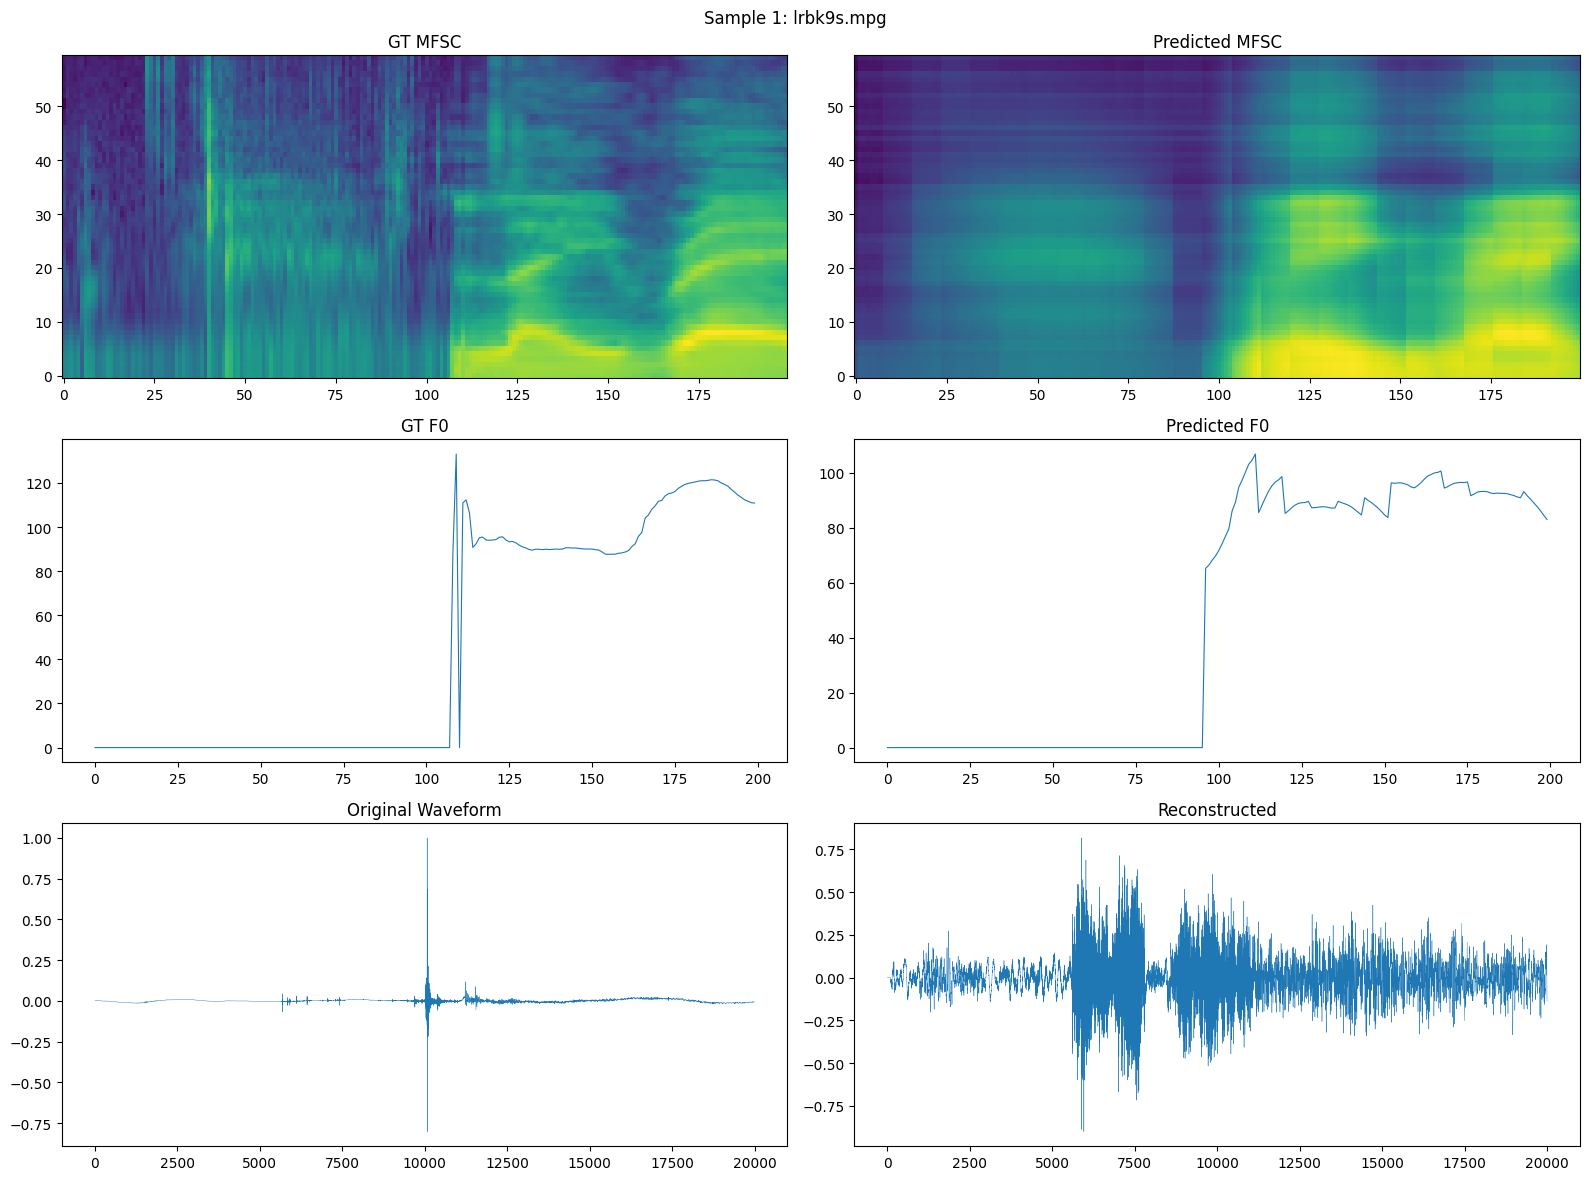


Sample 2/5: sran7s.mpg (s2)
  Saved reconstructed (3.00s)


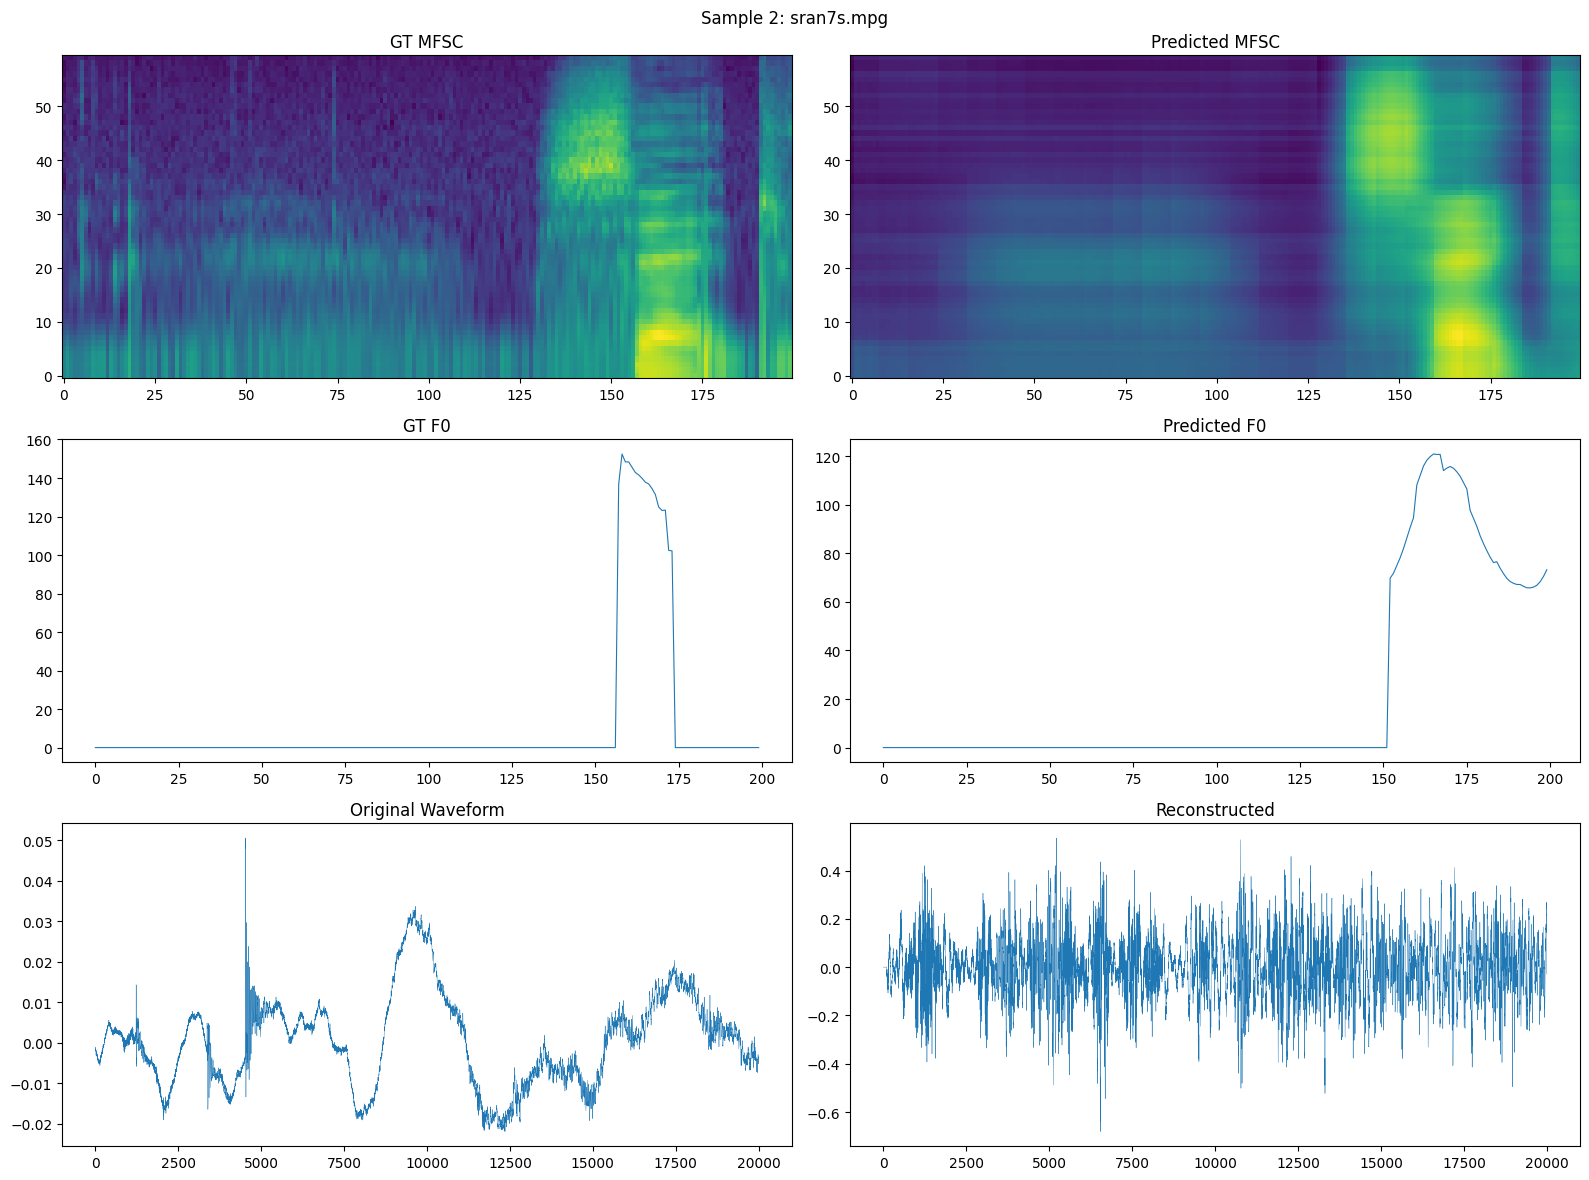


Sample 3/5: srbm9s.mpg (s5)
  Saved reconstructed (3.00s)


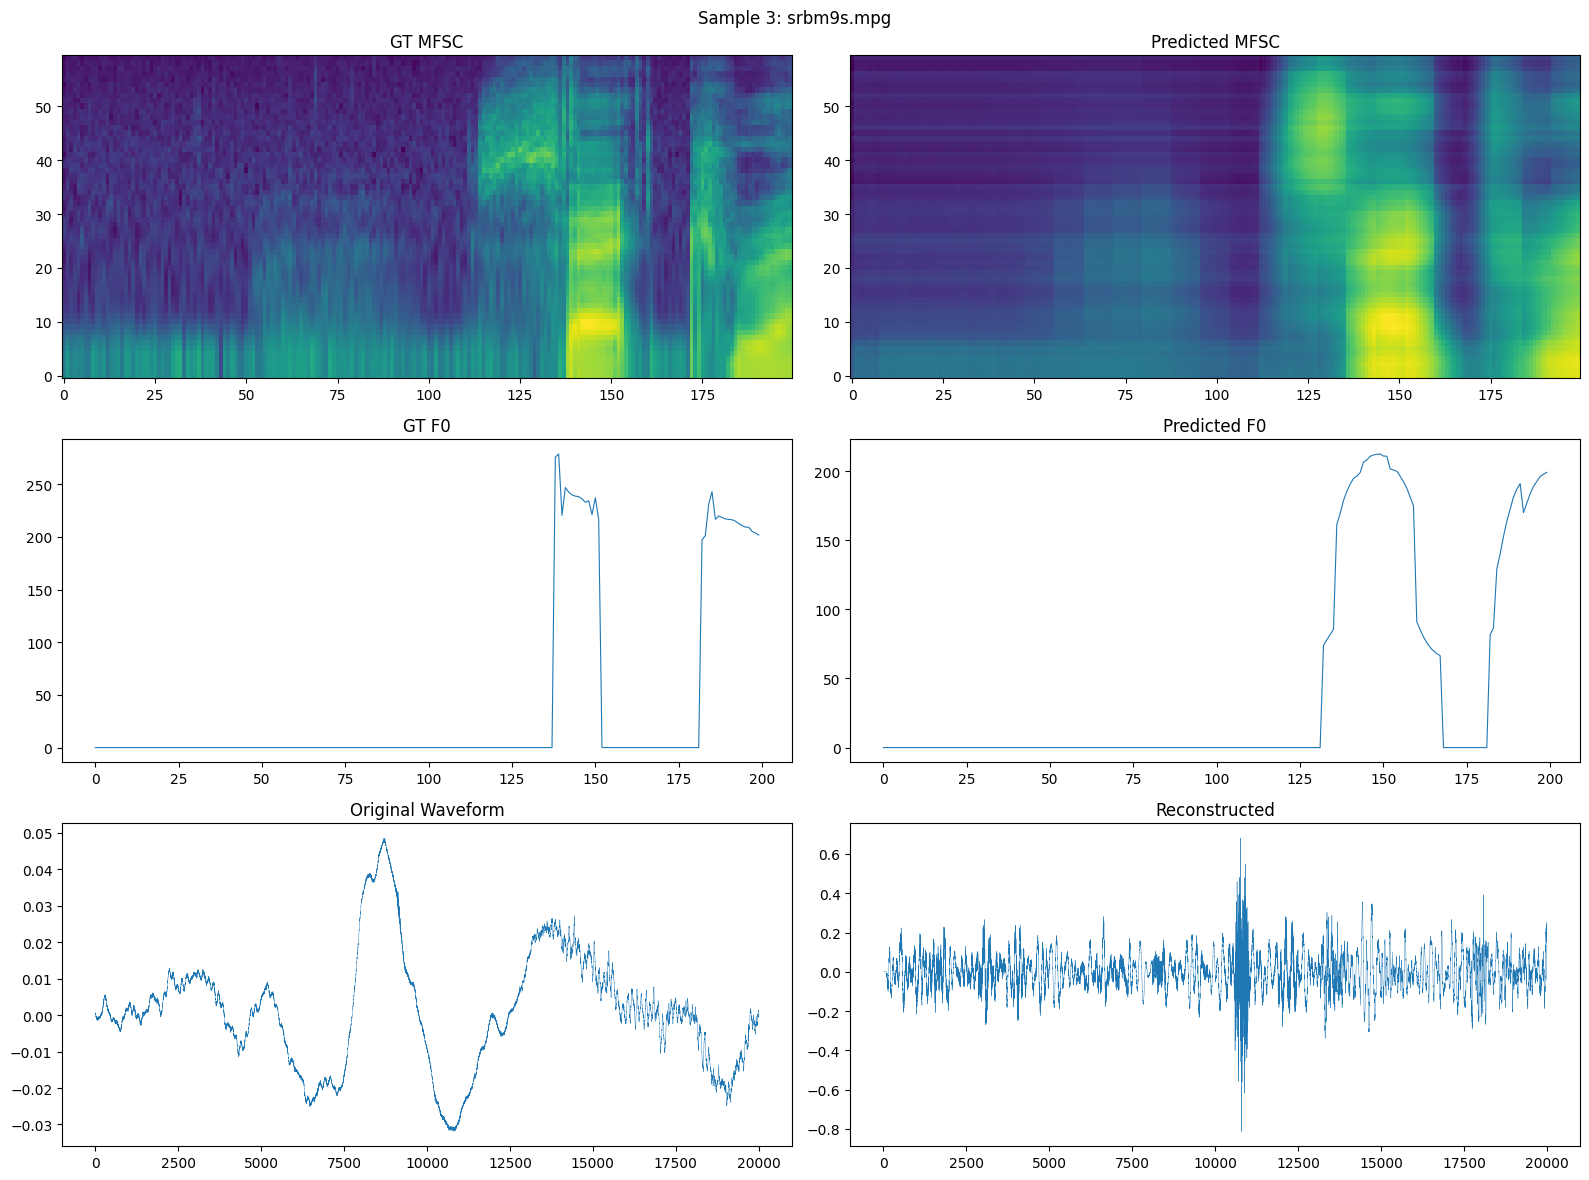


Sample 4/5: pbib6p.mpg (s2)
  Saved reconstructed (3.00s)


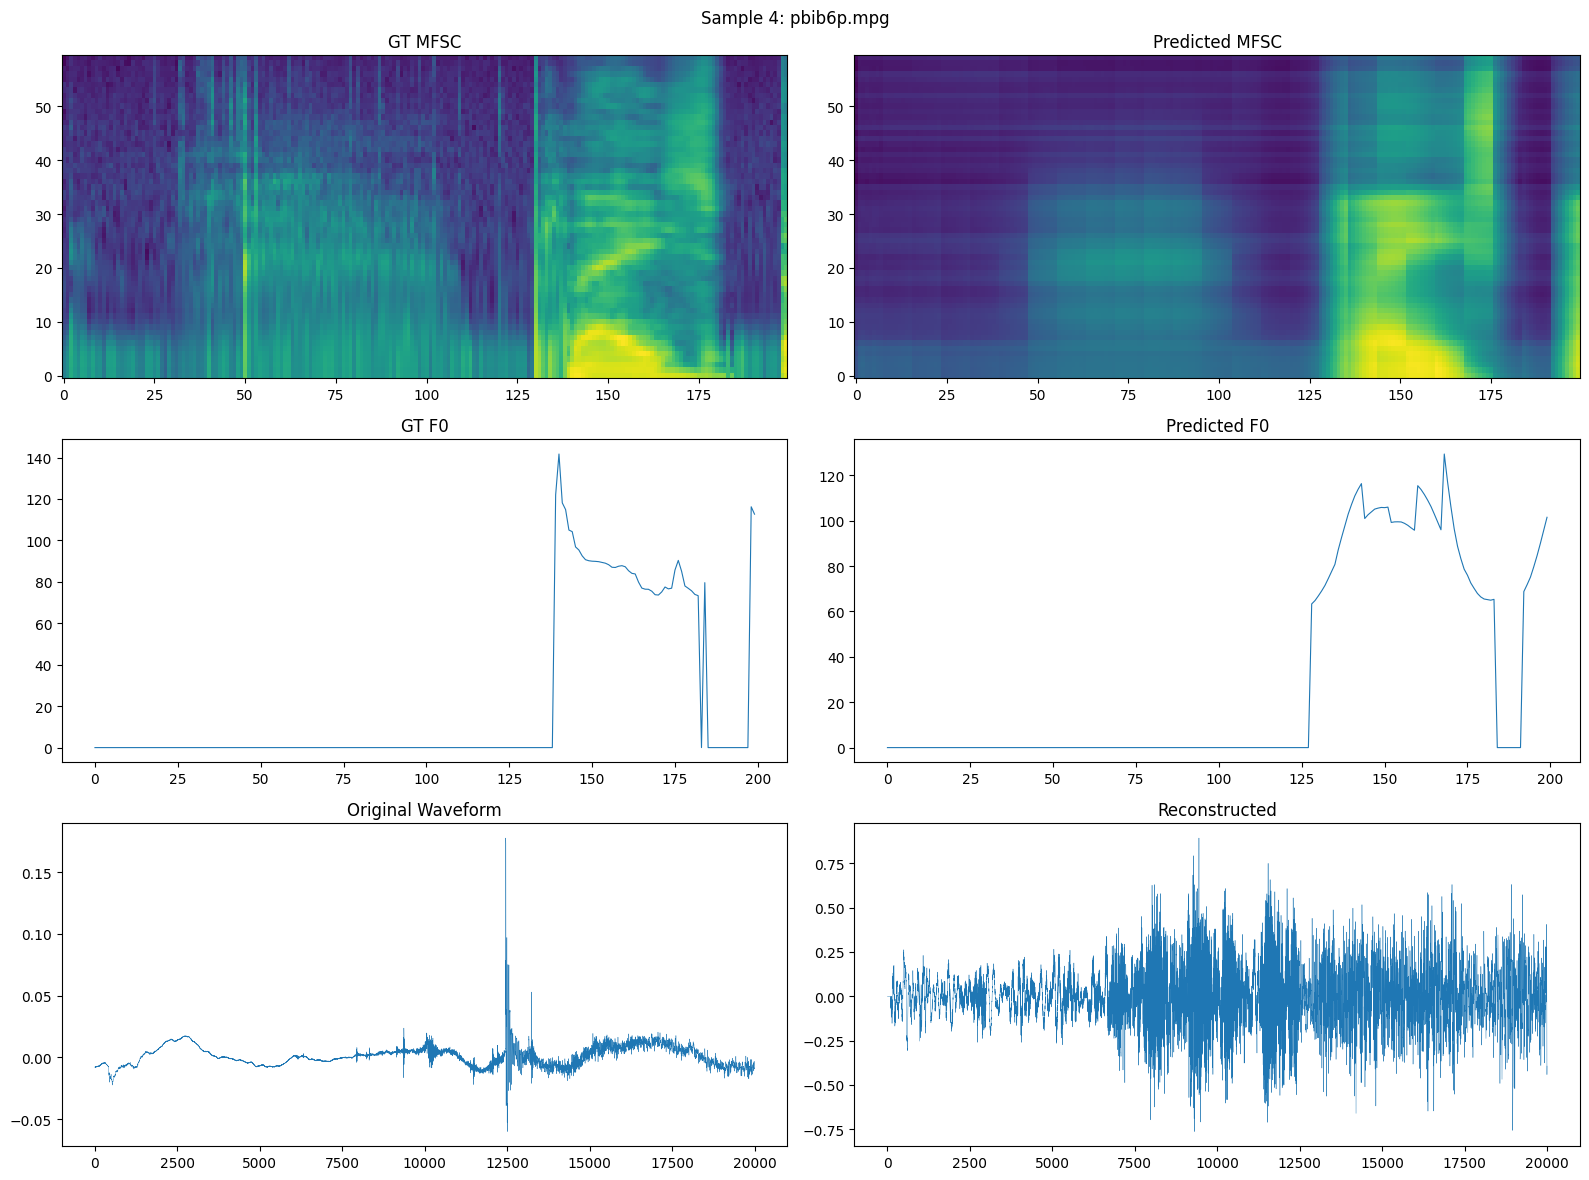


Sample 5/5: prbo4n.mpg (s5)
  Saved reconstructed (3.00s)


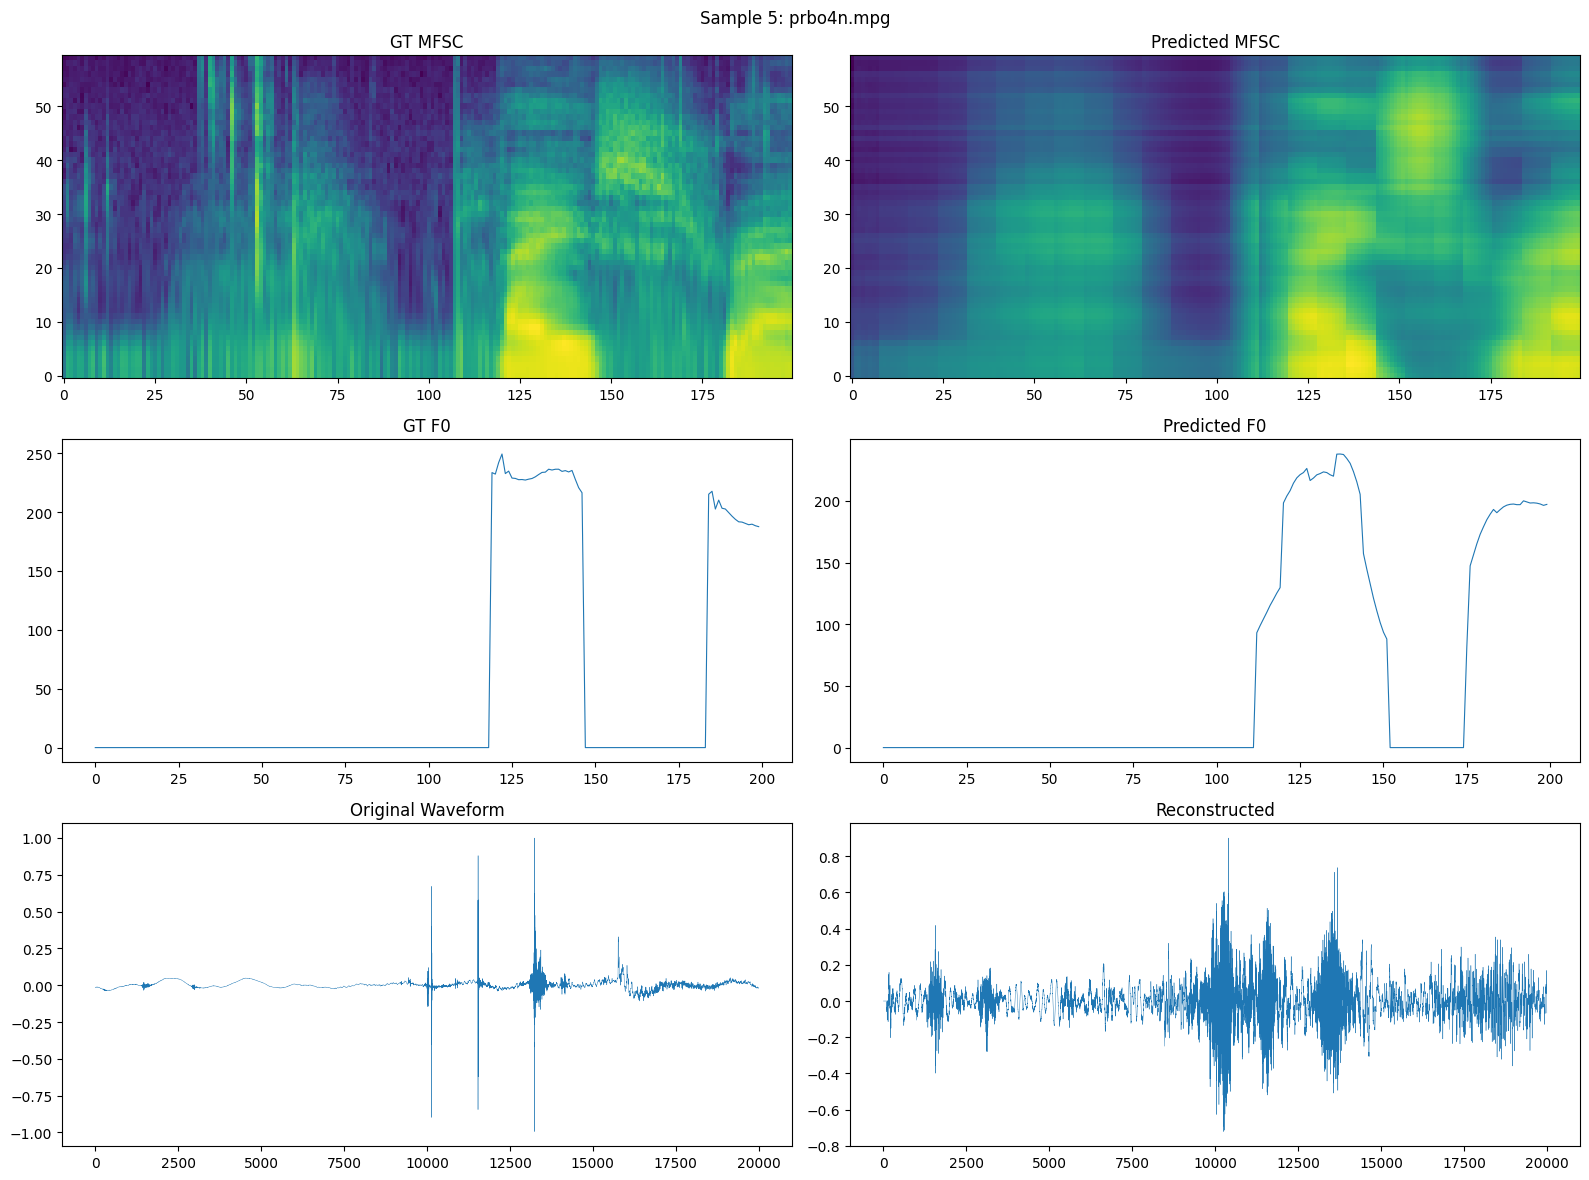


Inference complete! Outputs in outputs_vid2voc/


In [36]:
########################################################################
# CELL 16: INFERENCE AND AUDIO OUTPUT
########################################################################

ckpt_path = os.path.join(CHECKPOINT_DIR, 'vid2voc_best.pth')
if os.path.exists(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model, epoch {checkpoint['epoch']}, val_loss={checkpoint['val_loss']:.6f}")
model.eval()

os.makedirs('outputs_vid2voc', exist_ok=True)
num_samples = min(5, len(val_pairs))

for i in range(num_samples):
    sp_id, vp, ap_path = val_pairs[i]
    print(f"\nSample {i+1}/{num_samples}: {os.path.basename(vp)} ({sp_id})")

    frames = extract_video_frames(vp)
    frames_t = torch.FloatTensor(frames).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(frames_t)

    sp_p = pred['sp'][0].cpu().numpy()
    f0_p = pred['f0'][0].cpu().numpy()
    ap_p = pred['ap'][0].cpu().numpy()
    vuv_p = pred['vuv'][0].cpu().numpy()

    sp_flat = sp_p.transpose(0,2,1).reshape(-1, SP_DIM)
    f0_flat = f0_p.reshape(-1)
    ap_flat = ap_p.transpose(0,2,1).reshape(-1, AP_DIM)
    vuv_flat = vuv_p.reshape(-1)

    # ✅ FIX: pass audio_path
    pred_audio = reconstruct_world_audio(
        sp_flat, f0_flat, ap_flat, vuv_flat,
        audio_path=ap_path
    )

    sf.write(f'outputs_vid2voc/reconstructed_{i+1}.wav', pred_audio, SAMPLE_RATE)
    print(f"  Saved reconstructed ({len(pred_audio)/SAMPLE_RATE:.2f}s)")

    y_orig, _ = librosa.load(ap_path, sr=SAMPLE_RATE, mono=True)
    sf.write(f'outputs_vid2voc/original_{i+1}.wav', y_orig, SAMPLE_RATE)

    # GT WORLD resynthesis (upper bound)
    try:
        yd = y_orig.astype(np.float64)
        _f0g, _tg = pw.dio(yd, SAMPLE_RATE, frame_period=HOP_SIZE/SAMPLE_RATE*1000)
        f0g = pw.stonemask(yd, _f0g, _tg, SAMPLE_RATE)
        spg = pw.cheaptrick(yd, f0g, _tg, SAMPLE_RATE)
        apg = pw.d4c(yd, f0g, _tg, SAMPLE_RATE)
        yr = pw.synthesize(f0g, spg, apg, SAMPLE_RATE, frame_period=HOP_SIZE/SAMPLE_RATE*1000)
        if np.max(np.abs(yr)) > 0:
            yr = yr / np.max(np.abs(yr)) * 0.9
        sf.write(f'outputs_vid2voc/gt_resynth_{i+1}.wav', yr.astype(np.float32), SAMPLE_RATE)
    except:
        pass

    # Visualization
    gt_feats = extract_world_features(ap_path)
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    axes[0,0].imshow(gt_feats['mfsc'][:200].T, aspect='auto', origin='lower', cmap='viridis')
    axes[0,0].set_title('GT MFSC')
    axes[0,1].imshow(sp_flat[:200].T, aspect='auto', origin='lower', cmap='viridis')
    axes[0,1].set_title('Predicted MFSC')
    axes[1,0].plot(gt_feats['f0'][:200], lw=0.8)
    axes[1,0].set_title('GT F0')
    f0_vis = f0_flat[:200] * F0_RANGE + F0_MIN
    f0_vis[vuv_flat[:200] < 0.2] = 0
    axes[1,1].plot(f0_vis, lw=0.8)
    axes[1,1].set_title('Predicted F0')
    axes[2,0].plot(y_orig[:20000], lw=0.3)
    axes[2,0].set_title('Original Waveform')
    axes[2,1].plot(pred_audio[:20000], lw=0.3)
    axes[2,1].set_title('Reconstructed')
    fig.suptitle(f'Sample {i+1}: {os.path.basename(vp)}')
    plt.tight_layout()
    plt.savefig(f'outputs_vid2voc/comparison_{i+1}.png', dpi=150)
    plt.show()

print("\nInference complete! Outputs in outputs_vid2voc/")